In [49]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [50]:
p_con_vals      = np.linspace(0.05, 1.0, 39)
consensus_times = np.load(f"../data/voter/p_con/consensus_times.npy")
means           = np.mean(consensus_times,axis=1)
error           = np.std(consensus_times,axis=1)/np.sqrt(consensus_times.shape[1])

Text(0, 0.5, 'Interactions')

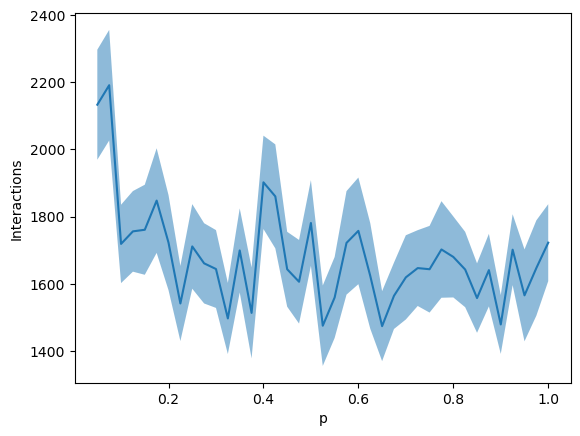

In [51]:
fig = plt.figure()
ax  = fig.add_subplot()
ax.plot(p_con_vals, means)
ax.fill_between(p_con_vals, means-error, means+error, alpha=0.5)
ax.set_xlabel("p")
ax.set_ylabel("Interactions")

In [52]:
p_noise_values  = np.linspace(0.0, 0.2, 10)
avg_opinion     = {p_noise : np.load(f"../data/voter/noise/avg_opinion_noise_{i}.npy") for i, p_noise in enumerate(p_noise_values)}
int_density     = {p_noise : np.load(f"../data/voter/noise/int_density_noise_{i}.npy") for i, p_noise in enumerate(p_noise_values)}

In [53]:
means   = np.array([np.mean(np.abs(arr[:,-1])) for _, arr in avg_opinion.items()])
error   = np.array([np.std(np.abs(arr[:,-1]))/np.sqrt(arr.shape[0]) for _, arr in avg_opinion.items()])

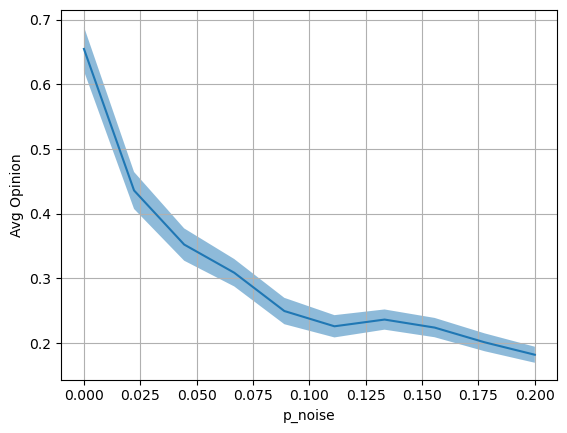

In [54]:
fig = plt.figure()
ax  = fig.add_subplot()
ax.plot(p_noise_values, means)
ax.fill_between(p_noise_values, means-error, means+error, alpha=0.5)
ax.set_xlabel("p_noise")
ax.set_ylabel("Avg Opinion")
ax.grid()

In [55]:
p_con_values    = np.linspace(0.05, 0.2, 17)
p_noise_values  = np.linspace(0.0, 0.1, 17)
data_phase      = np.load(f"../data/voter/phase/final_avg_opinions_phase_sweep.npy")
means           = np.mean(np.abs(data_phase), axis=2)

Text(0.5, 0, 'p_noise')

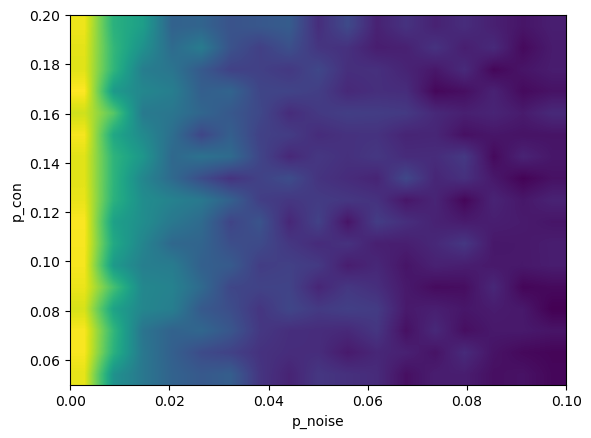

In [56]:
fig = plt.figure()
ax  = fig.add_subplot()
ax.imshow(means, extent=(p_noise_values[0],p_noise_values[-1],p_con_values[0],p_con_values[-1]),
          origin='lower', interpolation='bilinear', aspect='auto')
ax.set_ylabel("p_con")
ax.set_xlabel("p_noise")